# Sinkhole Risk — Data Visualization
Sarah Zahaykevich

## Setup

In [56]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import shap
import geopandas as gpd
from shapely.geometry import box
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_curve
from imblearn.over_sampling import SMOTE

warnings.filterwarnings('ignore')
shap.initjs()          # enable JS widgets for inline force plots

BASE = r'C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f'

FEATURE_COLUMNS = [
    'month',
    'prior_month_complaints',
    'complaints_in_last_3months',
    'breaks_last_month',
    'breaks_last_3_months',
    'monthly_rain',
    'rain_last_3_months',
    'pavement_rating',
    'elev_ft',
    'depth_ft',
    'neighboring_sinkhole_incidents',
    'neighboring_water_breaks',
]

FEATURE_LABELS = {
    'month':                        'Month of Year',
    'prior_month_complaints':       'Prior Month Complaints',
    'complaints_in_last_3months':   'Complaints (Last 3 Mo.)',
    'breaks_last_month':            'Water Breaks (Last Mo.)',
    'breaks_last_3_months':         'Water Breaks (Last 3 Mo.)',
    'monthly_rain':                 'Monthly Rainfall (in)',
    'rain_last_3_months':           'Rainfall (Last 3 Mo.)',
    'pavement_rating':              'Pavement Rating',
    'elev_ft':                      'Bedrock Elevation (ft)',
    'depth_ft':                     'Bedrock Depth (ft)',
    'neighboring_sinkhole_incidents': 'Neighbor Sinkhole Incidents',
    'neighboring_water_breaks':     'Neighbor Water Breaks',
}
print('Libraries loaded.')


Libraries loaded.


## 1. Load Data & Retrain Model

In [57]:
# Load all five feature files
df_311  = pd.read_csv(os.path.join(BASE, 'features_311_grid.csv'))
df_wat  = pd.read_csv(os.path.join(BASE, 'features_water_grid.csv'))
df_prcp = pd.read_csv(os.path.join(BASE, 'features_precipitation_grid.csv'))
df_pave = pd.read_csv(os.path.join(BASE, 'features_pavement_grid.csv'))
df_bed  = pd.read_csv(os.path.join(BASE, 'features_bedrock_grid.csv'))

df = df_311.copy()
df = df.merge(df_wat [['grid_id','year_month','breaks_last_month','breaks_last_3_months']], on=['grid_id','year_month'], how='left')
df = df.merge(df_prcp[['grid_id','year_month','monthly_rain','rain_last_3_months']],         on=['grid_id','year_month'], how='left')
df = df.merge(df_pave[['grid_id','year_month','pavement_rating']],                           on=['grid_id','year_month'], how='left')
df = df.merge(df_bed [['grid_id','elev_ft','depth_ft']],                                     on='grid_id',               how='left')

df['has_sinkhole'] = (df['complaint_count'] > 0).astype(int)
df = df[df['year_month'] >= '2020-04'].reset_index(drop=True)
df = df.dropna().reset_index(drop=True)

print(f'Dataset: {df.shape}  |  positive rate: {df["has_sinkhole"].mean():.3%}')


Dataset: (245388, 16)  |  positive rate: 11.628%


In [58]:
cutoff = '2024-01'
train = df[df['year_month'] <  cutoff]
test  = df[df['year_month'] >= cutoff]

X_train = train[FEATURE_COLUMNS];  y_train = train['has_sinkhole']
X_test  = test [FEATURE_COLUMNS];  y_test  = test ['has_sinkhole']

smote = SMOTE(random_state=42, sampling_strategy=0.2)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

rf = RandomForestClassifier(n_estimators=300, max_depth=12,
                             min_samples_leaf=10, min_samples_split=20,
                             random_state=42, n_jobs=-1)
rf.fit(X_train_res, y_train_res)

# Tune decision threshold with F-beta (beta=0.5)
y_proba = rf.predict_proba(X_test)[:, 1]
prec, rec, thr = precision_recall_curve(y_test, y_proba)
fbeta = (1 + 0.5**2) * (prec * rec) / (0.5**2 * prec + rec + 1e-9)
best_threshold = thr[np.argmax(fbeta)]

print(f'Model trained.  Optimal threshold: {best_threshold:.4f}')

# Latest-month predictions
latest_month = df['year_month'].max()
df_latest = df[df['year_month'] == latest_month].copy()
df_latest['sinkhole_probability'] = rf.predict_proba(df_latest[FEATURE_COLUMNS])[:, 1]
df_latest['prediction'] = (df_latest['sinkhole_probability'] >= best_threshold).astype(int)
df_latest = df_latest.sort_values('sinkhole_probability', ascending=False).reset_index(drop=True)

print(f'Latest month: {latest_month}  |  at-risk cells: {df_latest["prediction"].sum():,}')


Model trained.  Optimal threshold: 0.4200
Latest month: 2025-11  |  at-risk cells: 62


## 2. Why Is This Location High Risk? — SHAP Analysis

SHAP (SHapley Additive exPlanations) explains **each individual prediction** by decomposing
the model output into a sum of per-feature contributions.
- **Red bars → push risk UP** (feature value increases sinkhole probability)
- **Blue bars → push risk DOWN** (feature value decreases probability)
- The sum of all bars + the base rate (E[f(x)]) equals the model's final probability for that cell.


In [59]:
# Build SHAP TreeExplainer — uses the forest's exact tree structure (no approximations)
explainer = shap.TreeExplainer(rf)

# Compute SHAP values for every at-risk cell in the latest month
at_risk_df = df_latest[df_latest['prediction'] == 1].copy()
X_risk = at_risk_df[FEATURE_COLUMNS]

# shap_values() returns a 3D array (n_samples, n_features, n_classes) for RF classifiers
shap_vals_raw = explainer.shap_values(X_risk)
shap_vals     = shap_vals_raw[:, :, 1]   # class 1 = Sinkhole Risk
base_val      = explainer.expected_value[1]

print(f'SHAP values computed for {len(X_risk):,} at-risk cells.')
print(f'Base rate (E[f(x)]): {base_val:.4f}')


SHAP values computed for 62 at-risk cells.
Base rate (E[f(x)]): 0.1666


Saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\shap_waterfall_top5.png


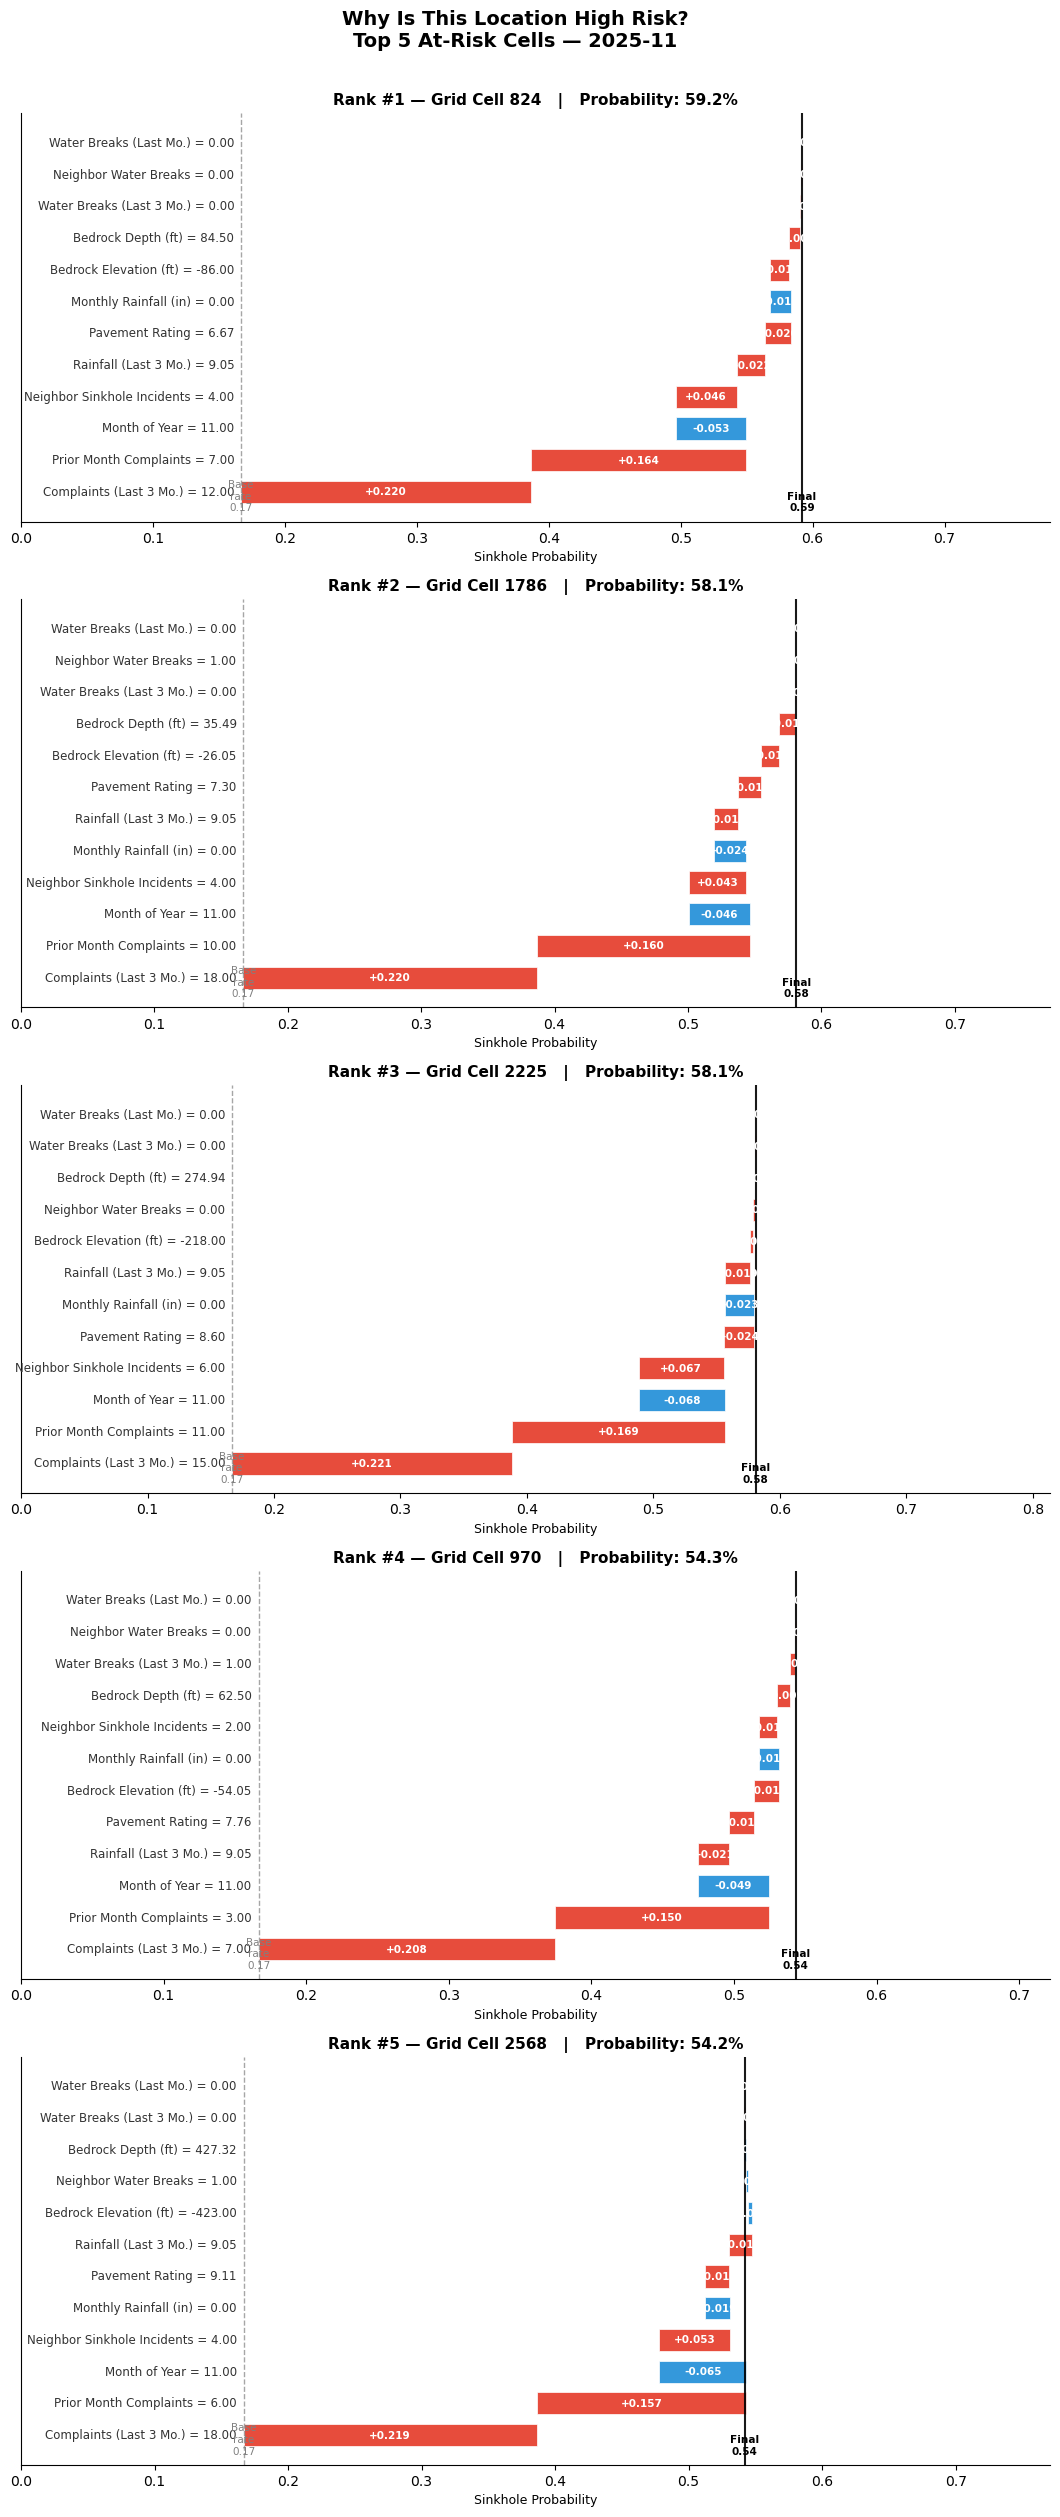

In [60]:
# ── Waterfall panel: Top 5 highest-risk cells ──────────────────────────────
# Each waterfall shows exactly which features drove that cell's prediction.

N_PANELS = min(5, len(X_risk))
readable_labels = [FEATURE_LABELS[f] for f in FEATURE_COLUMNS]

fig, axes = plt.subplots(N_PANELS, 1, figsize=(11, 5 * N_PANELS))
if N_PANELS == 1:
    axes = [axes]

for rank, ax in enumerate(axes):
    row_idx   = rank                         # already sorted desc by probability
    grid_id   = int(at_risk_df.iloc[row_idx]['grid_id'])
    prob      = at_risk_df.iloc[row_idx]['sinkhole_probability']
    sv        = shap_vals[row_idx]           # SHAP values for this cell
    feat_vals = X_risk.iloc[row_idx]

    # Sort features by absolute SHAP contribution
    order    = np.argsort(np.abs(sv))[::-1]
    sv_s     = sv[order]
    fv_s     = feat_vals.values[order]
    fl_s     = [readable_labels[i] for i in order]

    # Running cumulative sum for waterfall bars (start from base)
    cumulative = np.concatenate([[base_val], base_val + np.cumsum(sv_s)])
    colors     = ['#e74c3c' if v >= 0 else '#3498db' for v in sv_s]

    bars = ax.barh(
        y=range(len(sv_s)),
        width=sv_s,
        left=cumulative[:-1],
        color=colors,
        edgecolor='white',
        linewidth=0.5,
        height=0.7,
    )

    # Feature labels + values on left; SHAP magnitude on bars
    for i, (label, fval, sv_i) in enumerate(zip(fl_s, fv_s, sv_s)):
        ax.text(-0.005 + base_val, i,
                f'{label} = {fval:.2f}',
                ha='right', va='center', fontsize=8.5, color='#333333')
        sign = '+' if sv_i >= 0 else ''
        ax.text(cumulative[i] + sv_i / 2, i,
                f'{sign}{sv_i:.3f}',
                ha='center', va='center', fontsize=7.5,
                color='white', fontweight='bold')

    # Base and final value markers
    ax.axvline(base_val, color='grey', linestyle='--', linewidth=1, alpha=0.7)
    ax.axvline(prob,     color='black', linestyle='-',  linewidth=1.5, alpha=0.9)

    ax.set_yticks([])
    ax.set_xlabel('Sinkhole Probability', fontsize=9)
    ax.set_xlim(max(0, base_val - np.abs(sv_s).sum() - 0.05),
                min(1, base_val + np.abs(sv_s).sum() + 0.05))
    ax.set_title(
        f'Rank #{rank + 1} — Grid Cell {grid_id}   |   Probability: {prob:.1%}',
        fontsize=11, fontweight='bold', pad=6
    )
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    # Annotation: base rate and final probability
    ax.annotate(f'Base\nrate\n{base_val:.2f}',
                xy=(base_val, -0.6), fontsize=7.5, ha='center', color='grey')
    ax.annotate(f'Final\n{prob:.2f}',
                xy=(prob, -0.6), fontsize=7.5, ha='center', color='black', fontweight='bold')

fig.suptitle(
    f'Why Is This Location High Risk?\nTop {N_PANELS} At-Risk Cells — {latest_month}',
    fontsize=14, fontweight='bold', y=1.005
)
plt.tight_layout()
out = os.path.join(BASE, 'shap_waterfall_top5.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved to {out}')
plt.show()


Saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\shap_beeswarm.png


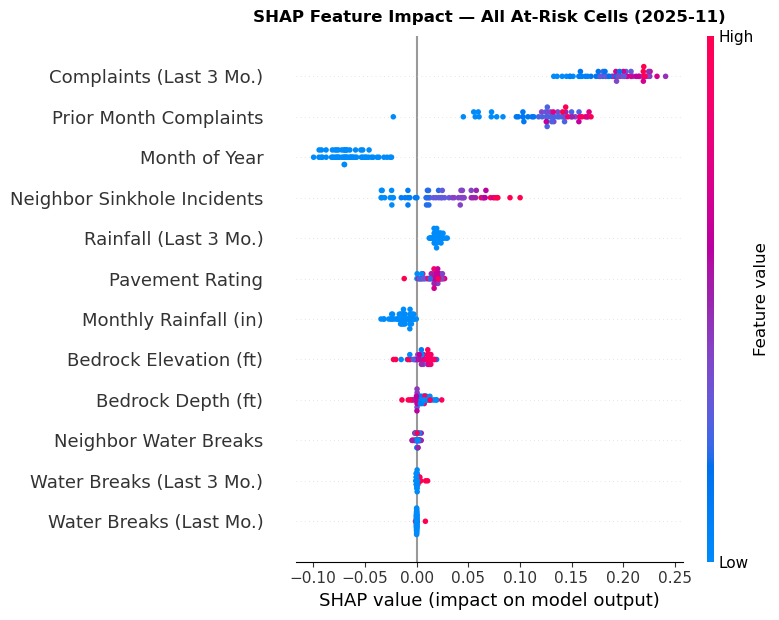

In [61]:
# ── SHAP Beeswarm: Global feature importance across ALL at-risk cells ───────
# Each dot = one cell; colour = feature value; x-axis = SHAP impact on probability.

shap_exp = shap.Explanation(
    values       = shap_vals,
    base_values  = np.full(len(shap_vals), base_val),
    data         = X_risk.values,
    feature_names= readable_labels,
)

plt.figure(figsize=(10, 6))
shap.plots.beeswarm(shap_exp, max_display=12, show=False)
plt.title(f'SHAP Feature Impact — All At-Risk Cells ({latest_month})',
          fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()
out = os.path.join(BASE, 'shap_beeswarm.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved to {out}')
plt.show()


Saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\shap_bar_summary.png


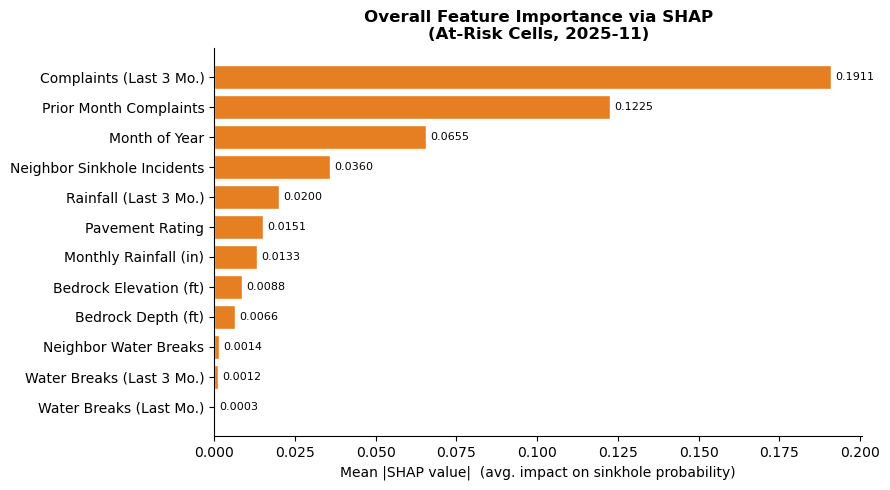

In [62]:
# ── SHAP Bar summary: Mean |SHAP| per feature (clean bar chart) ─────────────
mean_abs_shap = pd.DataFrame({
    'Feature':   readable_labels,
    'Mean |SHAP|': np.abs(shap_vals).mean(axis=0),
}).sort_values('Mean |SHAP|', ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(mean_abs_shap['Feature'], mean_abs_shap['Mean |SHAP|'],
               color='#e67e22', edgecolor='white')
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=8)
ax.set_xlabel('Mean |SHAP value|  (avg. impact on sinkhole probability)')
ax.set_title(f'Overall Feature Importance via SHAP\n(At-Risk Cells, {latest_month})',
             fontsize=12, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
out = os.path.join(BASE, 'shap_bar_summary.png')
plt.savefig(out, dpi=150, bbox_inches='tight')
print(f'Saved to {out}')
plt.show()


## 3. Export Charts as Interactive HTML

Each chart below is a fully interactive Plotly version saved as a self-contained HTML file.


In [63]:
import plotly.graph_objects as go

N_HTML = min(10, len(at_risk_df))   # export top-10 cells

# Pre-build one waterfall trace per cell; show the first by default
fig_wf = go.Figure()

for rank in range(N_HTML):
    grid_id = int(at_risk_df.iloc[rank]['grid_id'])
    prob    = at_risk_df.iloc[rank]['sinkhole_probability']
    sv      = shap_vals[rank]
    fv      = X_risk.iloc[rank]

    # Sort by absolute value descending
    order   = np.argsort(np.abs(sv))[::-1]
    sv_ord  = sv[order]
    fv_ord  = fv.values[order]
    fl_ord  = [readable_labels[i] for i in order]

    # Measure labels: "FeatureName = value"
    measure_labels = [f'{l} = {v:.2f}' for l, v in zip(fl_ord, fv_ord)]

    fig_wf.add_trace(go.Waterfall(
        name        = f'Cell {grid_id}',
        orientation = 'h',
        measure     = ['relative'] * len(sv_ord) + ['total'],
        y           = measure_labels + ['Final Probability'],
        x           = list(sv_ord) + [None],
        base        = base_val,
        visible     = (rank == 0),
        connector   = dict(line=dict(color='rgba(0,0,0,0.2)', width=1)),
        increasing  = dict(marker=dict(color='#e74c3c')),
        decreasing  = dict(marker=dict(color='#3498db')),
        totals      = dict(marker=dict(color='#2c3e50')),
        hovertemplate = '<b>%{y}</b><br>SHAP: %{x:+.4f}<extra></extra>',
    ))

# Dropdown buttons — one per cell
buttons = []
for rank in range(N_HTML):
    grid_id = int(at_risk_df.iloc[rank]['grid_id'])
    prob    = at_risk_df.iloc[rank]['sinkhole_probability']
    vis     = [i == rank for i in range(N_HTML)]
    buttons.append(dict(
        label  = f'#{rank+1}  Cell {grid_id}  ({prob:.1%})',
        method = 'update',
        args   = [{'visible': vis},
                  {'title': f'Why Is This Location High Risk?<br>'
                            f'Cell {grid_id} — Sinkhole Probability: {prob:.1%}'}],
    ))

fig_wf.update_layout(
    title = (f'Why Is This Location High Risk?<br>'
             f'Cell {int(at_risk_df.iloc[0]["grid_id"])} — '
             f'Sinkhole Probability: {at_risk_df.iloc[0]["sinkhole_probability"]:.1%}'),
    xaxis_title = 'Contribution to Sinkhole Probability',
    height      = 520,
    margin      = dict(l=280, r=40, t=100, b=60),
    plot_bgcolor= 'white',
    paper_bgcolor='white',
    updatemenus = [dict(
        type       = 'dropdown',
        x          = 1.0, y = 1.18,
        xanchor    = 'right', yanchor = 'top',
        buttons    = buttons,
        showactive = True,
    )],
    annotations = [dict(
        text     = f'Base rate: {base_val:.3f}',
        x        = base_val, y = -0.9,
        xref     = 'x', yref = 'paper',
        showarrow= False, font=dict(size=10, color='grey'),
    )],
)
fig_wf.add_vline(x=base_val, line_dash='dash', line_color='grey', line_width=1,
                 annotation_text='', annotation_position='top')

out_wf = os.path.join(BASE, 'shap_waterfall.html')
fig_wf.write_html(out_wf, include_plotlyjs='cdn', full_html=True)
print(f'Waterfall HTML saved to {out_wf}')
fig_wf.show()


Waterfall HTML saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\shap_waterfall.html


In [64]:
import plotly.graph_objects as go

# Normalise feature values to [0,1] per feature for colouring
X_arr   = shap_vals_raw[:, :, 1]   # (n_cells, n_features)
X_data  = X_risk.values
feat_min = X_data.min(axis=0)
feat_max = X_data.max(axis=0)
feat_norm = (X_data - feat_min) / np.where(feat_max - feat_min == 0, 1, feat_max - feat_min)

rng = np.random.default_rng(42)
fig_bee = go.Figure()

for fi, label in enumerate(readable_labels):
    sv_col  = shap_vals[:, fi]
    nv_col  = feat_norm[:, fi]
    fv_col  = X_data[:, fi]
    jitter  = rng.uniform(-0.35, 0.35, size=len(sv_col))

    fig_bee.add_trace(go.Scatter(
        x    = sv_col,
        y    = [fi + j for j in jitter],
        mode = 'markers',
        name = label,
        marker = dict(
            size   = 5,
            color  = nv_col,
            colorscale = [[0, '#3498db'], [0.5, '#ecf0f1'], [1, '#e74c3c']],
            cmin   = 0, cmax = 1,
            line   = dict(width=0),
            showscale = (fi == len(readable_labels) - 1),
            colorbar  = dict(
                title       = 'Feature<br>Value',
                tickvals    = [0, 0.5, 1],
                ticktext    = ['Low', 'Mid', 'High'],
                len         = 0.5, y = 0.5,
            ) if fi == len(readable_labels) - 1 else None,
        ),
        hovertemplate = (
            f'<b>{label}</b><br>'
            'SHAP: %{x:+.4f}<br>'
            'Feature value: ' + '%{customdata:.3f}<extra></extra>'
        ),
        customdata = fv_col,
    ))

fig_bee.update_layout(
    title      = f'SHAP Feature Impact — All At-Risk Cells ({latest_month})',
    xaxis_title= 'SHAP Value (impact on sinkhole probability)',
    yaxis      = dict(
        tickmode = 'array',
        tickvals = list(range(len(readable_labels))),
        ticktext = readable_labels,
        zeroline = False,
    ),
    height      = 560,
    showlegend  = False,
    plot_bgcolor= 'white',
    paper_bgcolor='white',
    margin      = dict(l=220, r=80, t=80, b=60),
)
fig_bee.add_vline(x=0, line_color='grey', line_width=1, line_dash='solid')

out_bee = os.path.join(BASE, 'shap_beeswarm.html')
fig_bee.write_html(out_bee, include_plotlyjs='cdn', full_html=True)
print(f'Beeswarm HTML saved to {out_bee}')
fig_bee.show()


Beeswarm HTML saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\shap_beeswarm.html


In [65]:
import plotly.express as px

mean_abs_shap_df = pd.DataFrame({
    'Feature'    : readable_labels,
    'Mean |SHAP|': np.abs(shap_vals).mean(axis=0),
}).sort_values('Mean |SHAP|', ascending=True)

fig_bar = px.bar(
    mean_abs_shap_df,
    x     = 'Mean |SHAP|',
    y     = 'Feature',
    orientation = 'h',
    color = 'Mean |SHAP|',
    color_continuous_scale = 'Oranges',
    text  = mean_abs_shap_df['Mean |SHAP|'].map(lambda v: f'{v:.4f}'),
    title = f'Overall Feature Importance via SHAP<br>(At-Risk Cells, {latest_month})',
    labels= {'Mean |SHAP|': 'Mean |SHAP Value|'},
)
fig_bar.update_traces(textposition='outside')
fig_bar.update_layout(
    height          = 480,
    coloraxis_showscale = False,
    plot_bgcolor    = 'white',
    paper_bgcolor   = 'white',
    margin          = dict(l=220, r=80, t=80, b=60),
    xaxis_title     = 'Mean |SHAP value|  (avg. impact on sinkhole probability)',
    yaxis_title     = '',
)

out_bar = os.path.join(BASE, 'shap_bar_summary.html')
fig_bar.write_html(out_bar, include_plotlyjs='cdn', full_html=True)
print(f'Bar summary HTML saved to {out_bar}')
fig_bar.show()


Bar summary HTML saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\shap_bar_summary.html


## 4. NYC Sinkhole Risk Dashboard

City-level stats, borough breakdowns, and a risk trend over time — all in one interactive HTML dashboard.


In [66]:
import geopandas as gpd
from shapely.geometry import box
from plotly.subplots import make_subplots
import plotly.graph_objects as go

# ── 1. Assign every grid cell a borough via spatial join ─────────────────────
nyc = gpd.read_file(r'C:\Users\szaha\Downloads\Borough_Boundaries_20260328.geojson').to_crs(epsg=32618)
nyc_union = nyc.dissolve().reset_index(drop=True)

xmin, ymin, xmax, ymax = nyc_union.total_bounds
cell_size = 500
grid_cells_geom = [box(x, y, x+cell_size, y+cell_size)
                   for x in np.arange(xmin, xmax, cell_size)
                   for y in np.arange(ymin, ymax, cell_size)]
grid = gpd.GeoDataFrame(geometry=grid_cells_geom, crs=nyc_union.crs)
grid_clipped = gpd.overlay(grid, nyc_union, how='intersection').reset_index(drop=True)
grid_clipped['grid_id'] = range(len(grid_clipped))

# Borough column name
boro_col = [c for c in nyc.columns if 'boro' in c.lower() and 'name' in c.lower()][0]
nyc_boros = nyc[['geometry', boro_col]].copy()

grid_with_boro = gpd.sjoin(
    grid_clipped[['grid_id','geometry']],
    nyc_boros,
    how='left', predicate='intersects'
).drop_duplicates('grid_id')[['grid_id', boro_col]].rename(columns={boro_col: 'borough'})

print(f'Grid cells with borough: {len(grid_with_boro):,}')
print(grid_with_boro['borough'].value_counts())


Grid cells with borough: 3,718
borough
Queens           1305
Brooklyn          877
Staten Island     693
Bronx             527
Manhattan         316
Name: count, dtype: int64


In [67]:
# ── 2. Monthly trend: run predictions for every month in the full dataset ────
monthly_rows = []
for ym in sorted(df['year_month'].unique()):
    df_m = df[df['year_month'] == ym]
    proba = rf.predict_proba(df_m[FEATURE_COLUMNS])[:, 1]
    pred  = (proba >= best_threshold).astype(int)
    monthly_rows.append({
        'year_month':    ym,
        'pct_at_risk':   pred.mean() * 100,
        'n_at_risk':     int(pred.sum()),
        'avg_prob':      float(proba.mean()),
        'n_cells':       len(pred),
    })
monthly_df = pd.DataFrame(monthly_rows)
monthly_df['period'] = np.where(monthly_df['year_month'] < '2024-01', 'Train', 'Test')
print(monthly_df.tail())

# ── 3. Latest-month borough stats ────────────────────────────────────────────
latest_with_boro = df_latest[['grid_id','sinkhole_probability','prediction']].merge(
    grid_with_boro, on='grid_id', how='left'
)
boro_stats = latest_with_boro.groupby('borough').agg(
    avg_risk  = ('sinkhole_probability', 'mean'),
    n_at_risk = ('prediction', 'sum'),
    n_cells   = ('grid_id', 'count'),
).reset_index().sort_values('avg_risk', ascending=False)
boro_stats['pct_at_risk'] = (boro_stats['n_at_risk'] / boro_stats['n_cells'] * 100).round(1)
print(boro_stats)


   year_month  pct_at_risk  n_at_risk  avg_prob  n_cells period
61    2025-07    16.487359        613  0.256422     3718   Test
62    2025-08    21.490048        799  0.303143     3718   Test
63    2025-09    14.335664        533  0.249142     3718   Test
64    2025-10     7.961269        296  0.200306     3718   Test
65    2025-11     1.667563         62  0.129321     3718   Test
         borough  avg_risk  n_at_risk  n_cells  pct_at_risk
2      Manhattan  0.172429         16      316          5.1
1       Brooklyn  0.146299         15      877          1.7
3         Queens  0.138337         21     1305          1.6
0          Bronx  0.118638          8      527          1.5
4  Staten Island  0.079325          2      693          0.3


In [68]:
from geopy.geocoders import Nominatim
from geopy.extra.rate_limiter import RateLimiter

# ── Helper: build a short human-readable label from Nominatim address dict ───
def _location_label(addr):
    road  = addr.get('road', '')
    neigh = addr.get('neighbourhood', '') or addr.get('suburb', '')
    # Map county → borough name
    boro_map = {
        'Kings County':    'Brooklyn',
        'New York County': 'Manhattan',
        'Queens County':   'Queens',
        'Bronx County':    'The Bronx',
        'Richmond County': 'Staten Island',
    }
    borough = boro_map.get(addr.get('county', ''), addr.get('suburb', ''))
    parts = [p for p in [road, neigh if neigh != borough else '', borough] if p]
    return ', '.join(dict.fromkeys(parts))   # deduplicate while preserving order

# ── Cache so we only call Nominatim once per cell ────────────────────────────
cache_path = os.path.join(BASE, 'grid_locations_cache.csv')
if os.path.exists(cache_path):
    cache_df = pd.read_csv(cache_path)
    cache_df['grid_id'] = cache_df['grid_id'].astype(int)
else:
    cache_df = pd.DataFrame(columns=['grid_id', 'location_label'])

top10_ids    = df_latest.head(10)['grid_id'].tolist()
missing_ids  = [gid for gid in top10_ids if gid not in cache_df['grid_id'].values]

if missing_ids:
    # Get centroids in WGS84 for the cells that are not yet cached
    cells_geom = grid_clipped[grid_clipped['grid_id'].isin(missing_ids)].copy()
    cells_geom = cells_geom.to_crs(epsg=4326)
    cells_geom['lat'] = cells_geom.geometry.centroid.y
    cells_geom['lon'] = cells_geom.geometry.centroid.x

    geolocator = Nominatim(user_agent='nyc_sinkhole_dashboard_v1')
    reverse    = RateLimiter(geolocator.reverse, min_delay_seconds=1.1)

    new_rows = []
    for _, row in cells_geom.iterrows():
        result = reverse((row['lat'], row['lon']), language='en')
        label  = _location_label(result.raw.get('address', {})) if result else f'Cell {int(row["grid_id"])}'
        new_rows.append({'grid_id': int(row['grid_id']), 'location_label': label})
        print(f'  Cell {int(row["grid_id"])}: {label}')

    cache_df = pd.concat([cache_df, pd.DataFrame(new_rows)], ignore_index=True)
    cache_df.to_csv(cache_path, index=False)
    print(f'Cache updated: {len(cache_df)} entries')
else:
    print('All top-10 locations already cached.')

# Merge location labels onto df_latest
df_latest = df_latest.merge(
    cache_df[['grid_id','location_label']], on='grid_id', how='left'
)
df_latest['location_label'] = df_latest['location_label'].fillna(
    'Cell ' + df_latest['grid_id'].astype(str)
)
print(df_latest[['grid_id','sinkhole_probability','location_label']].head(10).to_string(index=False))


All top-10 locations already cached.
 grid_id  sinkhole_probability                                     location_label
     824              0.591950                       Broadway, Tribeca, Manhattan
    1786              0.581077                       East 157th Street, The Bronx
    2225              0.580937                              Denman Street, Queens
     970              0.543287 8th Avenue, Manhattan Community Board 5, Manhattan
    2568              0.541815                   68th Drive, Forest Hills, Queens
    1333              0.531455                           Hopkins Street, Brooklyn
     767              0.531402               77th Street, Dyker Heights, Brooklyn
    2172              0.528767                        Evergreen Avenue, The Bronx
     888              0.527565              Bay 29th Street, Bath Beach, Brooklyn
    1108              0.525782              Adelphi Street, Fort Greene, Brooklyn


Dashboard HTML saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\sinkhole_dashboard.html


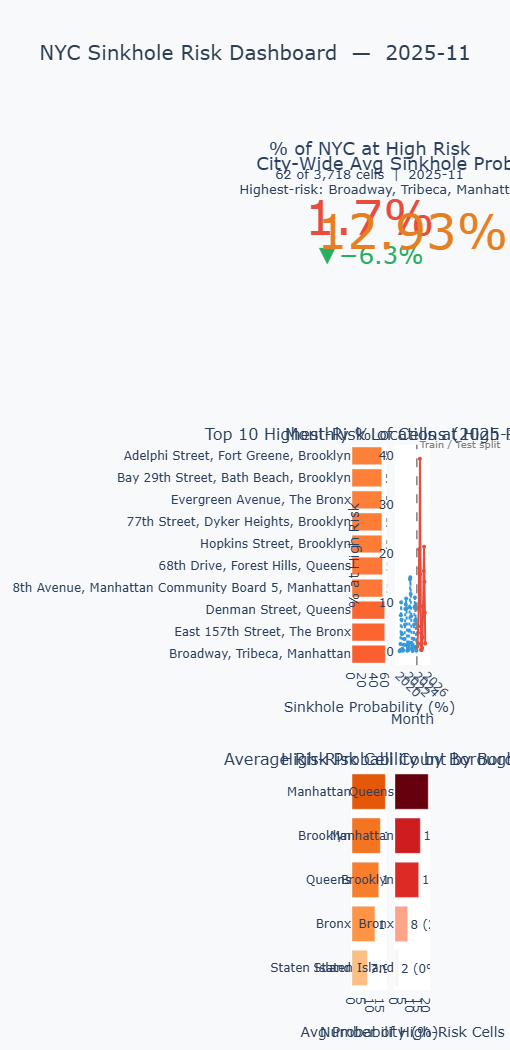

In [73]:
# ── City-level KPIs ──────────────────────────────────────────────────────────
total_cells   = len(df_latest)
n_at_risk_now = int(df_latest['prediction'].sum())
pct_at_risk   = n_at_risk_now / total_cells * 100
avg_prob      = df_latest['sinkhole_probability'].mean()
top1          = df_latest.iloc[0]

# ── Top 10 highest-risk cells ────────────────────────────────────────────────
top10 = df_latest.head(10).copy()
top10['label'] = top10['location_label']

# ── Build dashboard (5 panels) ───────────────────────────────────────────────
fig = make_subplots(
    rows=3, cols=2,
    specs=[
        [{'type': 'indicator'}, {'type': 'indicator'}],
        [{'type': 'xy'},        {'type': 'xy'}],
        [{'type': 'xy'},        {'type': 'xy'}],
    ],
    subplot_titles=(
        '', '',
        f'Top 10 Highest-Risk Locations ({latest_month})',
        'Monthly % of Cells at High Risk',
        'Average Risk Probability by Borough',
        'High-Risk Cell Count by Borough',
    ),
    vertical_spacing  = 0.12,
    horizontal_spacing= 0.10,
)

# Row 1 — KPI gauges
fig.add_trace(go.Indicator(
    mode  = 'number+delta',
    value = pct_at_risk,
    title = dict(text='% of NYC at High Risk<br><span style="font-size:13px">'
                      f'{n_at_risk_now:,} of {total_cells:,} cells  |  {latest_month}</span>',
                 font=dict(size=18)),
    number= dict(suffix='%', valueformat='.1f', font=dict(size=48, color='#e74c3c')),
    delta = dict(reference=monthly_df.iloc[-2]['pct_at_risk'],
                 relative=False, valueformat='.1f', suffix='%',
                 increasing=dict(color='#e74c3c'), decreasing=dict(color='#27ae60')),
), row=1, col=1)

fig.add_trace(go.Indicator(
    mode  = 'number',
    value = avg_prob * 100,
    title = dict(text='City-Wide Avg Sinkhole Probability<br>'
                      f'<span style="font-size:13px">Highest-risk: {top1["location_label"]} ({top1["sinkhole_probability"]:.1%})</span>',
                 font=dict(size=18)),
    number= dict(suffix='%', valueformat='.2f', font=dict(size=48, color='#e67e22')),
), row=1, col=2)

# Row 2 left — Top 10 bar
fig.add_trace(go.Bar(
    x           = top10['sinkhole_probability'] * 100,
    y           = top10['label'],
    orientation = 'h',
    marker_color = top10['sinkhole_probability'],
    marker_colorscale='YlOrRd',
    marker_cmin=0, marker_cmax=1,
    text        = (top10['sinkhole_probability'] * 100).map('{:.1f}%'.format),
    textposition= 'outside',
    customdata  = top10['grid_id'],
    hovertemplate=(
        '<b>%{y}</b><br>'
        'Probability: %{x:.1f}%<br>'
        'Grid cell: %{customdata}<extra></extra>'
    ),
), row=2, col=1)

# Row 2 right — Trend line (split train/test)
for period, colour, dash in [('Train','#3498db','dot'), ('Test','#e74c3c','solid')]:
    sub = monthly_df[monthly_df['period'] == period]
    fig.add_trace(go.Scatter(
        x=sub['year_month'], y=sub['pct_at_risk'],
        mode='lines+markers', name=period,
        line=dict(color=colour, width=2, dash=dash),
        marker=dict(size=4),
        hovertemplate='%{x}<br>At-risk: %{y:.2f}%<extra>' + period + '</extra>',
    ), row=2, col=2)

# Cutoff line — add_vline fails on mixed-type subplot grids, use add_shape instead
fig.add_shape(
    type='line', x0='2024-01', x1='2024-01', y0=0, y1=1,
    xref='x2', yref='y2 domain',
    line=dict(dash='dash', color='grey', width=1.5),
)
fig.add_annotation(
    x='2024-01', y=1.04, xref='x2', yref='y2 domain',
    text='Train / Test split', showarrow=False,
    font=dict(size=10, color='grey'), xanchor='left',
)

# Row 3 left — Avg risk by borough
boro_sorted_avg = boro_stats.sort_values('avg_risk')
fig.add_trace(go.Bar(
    x=boro_sorted_avg['avg_risk'] * 100,
    y=boro_sorted_avg['borough'],
    orientation='h',
    marker_color=boro_sorted_avg['avg_risk'],
    marker_colorscale='Oranges', marker_cmin=0, marker_cmax=0.25,
    text=(boro_sorted_avg['avg_risk'] * 100).map('{:.2f}%'.format),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>Avg probability: %{x:.2f}%<extra></extra>',
), row=3, col=1)

# Row 3 right — High-risk count by borough
boro_sorted_n = boro_stats.sort_values('n_at_risk')
fig.add_trace(go.Bar(
    x=boro_sorted_n['n_at_risk'],
    y=boro_sorted_n['borough'],
    orientation='h',
    marker_color=boro_sorted_n['n_at_risk'],
    marker_colorscale='Reds', marker_cmin=0,
    text=boro_sorted_n.apply(
        lambda r: f'{int(r["n_at_risk"])} ({r["pct_at_risk"]:.0f}%)', axis=1),
    textposition='outside',
    hovertemplate='<b>%{y}</b><br>At-risk cells: %{x}<extra></extra>',
), row=3, col=2)

# ── Layout ───────────────────────────────────────────────────────────────────
fig.update_layout(
    title      = dict(
        text = f'NYC Sinkhole Risk Dashboard  —  {latest_month}',
        font = dict(size=20, color='#2c3e50'),
        x    = 0.5, xanchor='center',
    ),
    height     = 1050,
    showlegend = False,
    legend     = dict(x=0.72, y=0.62, bgcolor='rgba(255,255,255,0.8)'),
    plot_bgcolor  = 'white',
    paper_bgcolor = '#f8f9fa',
    margin     = dict(l=260, r=80, t=120, b=60),
)

# Axis labels
fig.update_xaxes(title_text='Sinkhole Probability (%)', row=2, col=1)
fig.update_xaxes(title_text='Month', row=2, col=2, tickangle=45)
fig.update_yaxes(title_text='% at High Risk', row=2, col=2)
fig.update_xaxes(title_text='Avg Probability (%)', row=3, col=1)
fig.update_xaxes(title_text='Number of High-Risk Cells', row=3, col=2)

# Save interactive HTML
out_dash_html = os.path.join(BASE, 'sinkhole_dashboard.html')
fig.write_html(out_dash_html, include_plotlyjs='cdn', full_html=True)
print(f'Dashboard HTML saved to {out_dash_html}')
fig.show()


Dashboard PNG saved to C:\Users\szaha\anaconda_projects\7bddeb11-5afb-41ab-a725-816dd757e48f\sinkhole_dashboard.png


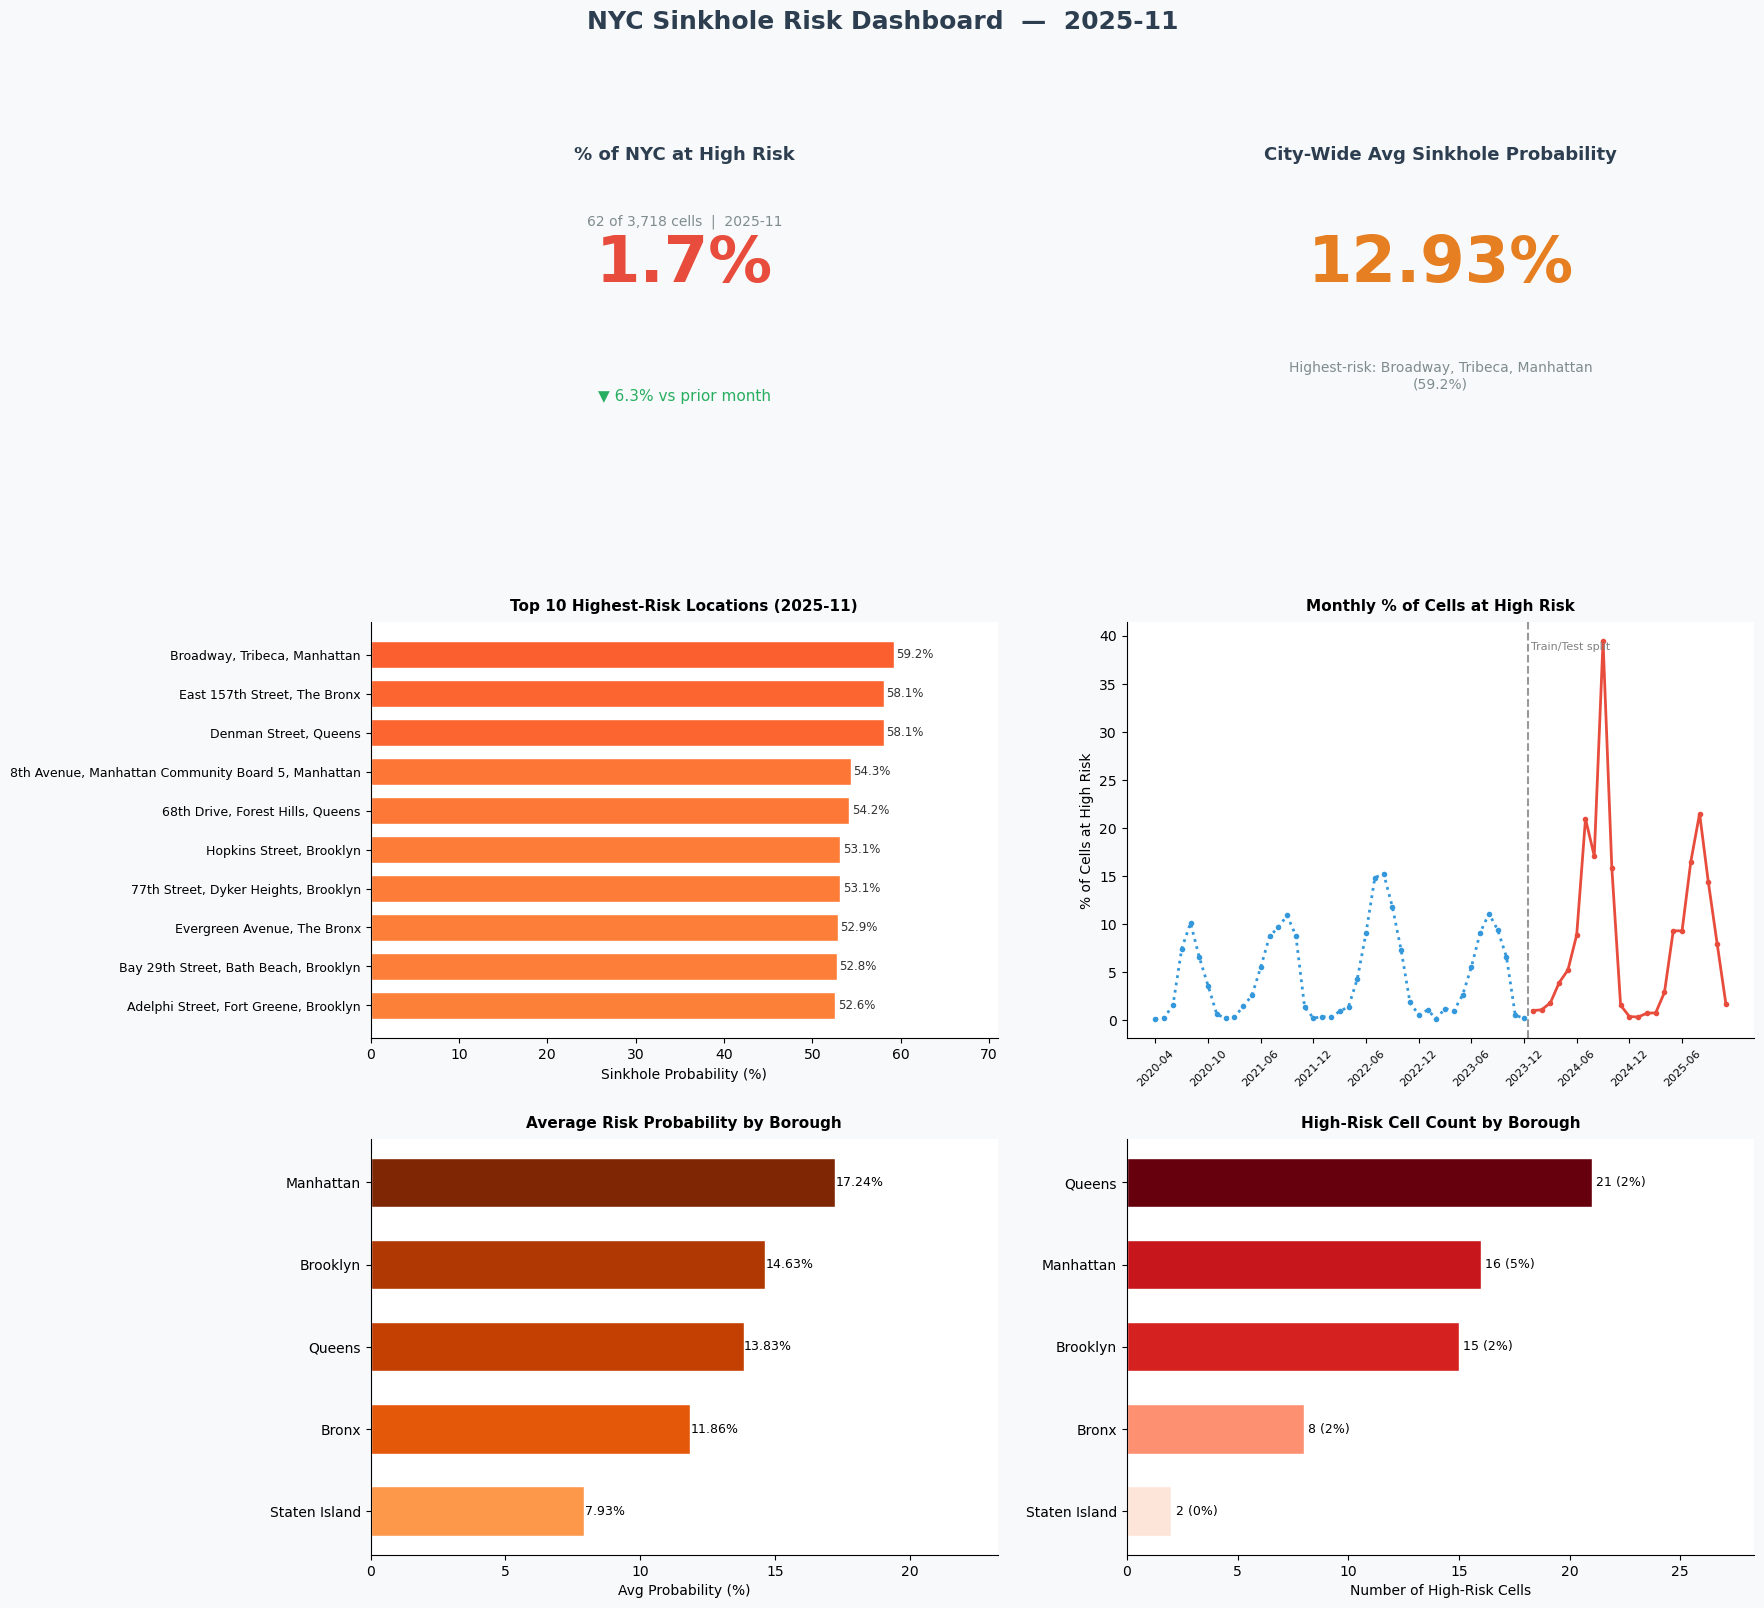

In [72]:
# ── Static PNG dashboard using matplotlib ────────────────────────────────────
# (Plotly's write_image requires kaleido which may not render in all environments)

fig_png, axes = plt.subplots(3, 2, figsize=(18, 16))
fig_png.patch.set_facecolor('#f8f9fa')

# ── Row 1: KPI text boxes ────────────────────────────────────────────────────
for ax in axes[0]:
    ax.set_axis_off()
    ax.set_facecolor('white')
    for spine in ax.spines.values():
        spine.set_visible(True); spine.set_linewidth(1.5); spine.set_edgecolor('#dee2e6')

# Left KPI: % at risk
delta = pct_at_risk - monthly_df.iloc[-2]['pct_at_risk']
delta_str  = f'{"▲" if delta >= 0 else "▼"} {abs(delta):.1f}% vs prior month'
delta_col  = '#e74c3c' if delta >= 0 else '#27ae60'
axes[0,0].text(0.5, 0.62, f'{pct_at_risk:.1f}%',
               ha='center', va='center', fontsize=46, fontweight='bold',
               color='#e74c3c', transform=axes[0,0].transAxes)
axes[0,0].text(0.5, 0.88, '% of NYC at High Risk',
               ha='center', va='center', fontsize=13, fontweight='bold',
               color='#2c3e50', transform=axes[0,0].transAxes)
axes[0,0].text(0.5, 0.72, f'{n_at_risk_now:,} of {total_cells:,} cells  |  {latest_month}',
               ha='center', va='center', fontsize=10, color='#7f8c8d',
               transform=axes[0,0].transAxes)
axes[0,0].text(0.5, 0.30, delta_str,
               ha='center', va='center', fontsize=11, color=delta_col,
               transform=axes[0,0].transAxes)

# Right KPI: avg probability
axes[0,1].text(0.5, 0.62, f'{avg_prob*100:.2f}%',
               ha='center', va='center', fontsize=46, fontweight='bold',
               color='#e67e22', transform=axes[0,1].transAxes)
axes[0,1].text(0.5, 0.88, 'City-Wide Avg Sinkhole Probability',
               ha='center', va='center', fontsize=13, fontweight='bold',
               color='#2c3e50', transform=axes[0,1].transAxes)
axes[0,1].text(0.5, 0.35,
               f'Highest-risk: {top1["location_label"]}\n({top1["sinkhole_probability"]:.1%})',
               ha='center', va='center', fontsize=10, color='#7f8c8d',
               transform=axes[0,1].transAxes)

# ── Row 2 left: Top 10 bar ────────────────────────────────────────────────────
ax_top10 = axes[1, 0]
ax_top10.set_facecolor('white')
probs  = top10['sinkhole_probability'].values * 100
labels = top10['label'].values
colors = plt.cm.YlOrRd(top10['sinkhole_probability'].values)
bars   = ax_top10.barh(range(len(labels)), probs, color=colors, edgecolor='white', height=0.7)
ax_top10.set_yticks(range(len(labels)))
ax_top10.set_yticklabels(labels, fontsize=9)
ax_top10.set_xlabel('Sinkhole Probability (%)', fontsize=10)
ax_top10.set_title(f'Top 10 Highest-Risk Locations ({latest_month})',
                   fontsize=11, fontweight='bold', pad=8)
ax_top10.invert_yaxis()
for i, (bar, prob) in enumerate(zip(bars, probs)):
    ax_top10.text(prob + 0.3, i, f'{prob:.1f}%', va='center', fontsize=8.5, color='#333')
ax_top10.spines['top'].set_visible(False); ax_top10.spines['right'].set_visible(False)
ax_top10.set_xlim(0, max(probs) * 1.2)

# ── Row 2 right: Monthly trend ────────────────────────────────────────────────
ax_trend = axes[1, 1]
ax_trend.set_facecolor('white')
train_sub = monthly_df[monthly_df['period'] == 'Train']
test_sub  = monthly_df[monthly_df['period'] == 'Test']
ax_trend.plot(range(len(train_sub)), train_sub['pct_at_risk'].values,
              color='#3498db', linewidth=2, linestyle=':', marker='o', markersize=3, label='Train')
ax_trend.plot(range(len(train_sub), len(monthly_df)),
              test_sub['pct_at_risk'].values,
              color='#e74c3c', linewidth=2, marker='o', markersize=3, label='Test')
split_x = len(train_sub) - 0.5
ax_trend.axvline(split_x, color='grey', linestyle='--', linewidth=1.5, alpha=0.8)
ax_trend.text(split_x + 0.3, ax_trend.get_ylim()[1] * 0.95,
              'Train/Test split', fontsize=8, color='grey', va='top')
# X-axis: show every 6th label
all_months = monthly_df['year_month'].tolist()
tick_pos   = list(range(0, len(all_months), 6))
ax_trend.set_xticks(tick_pos)
ax_trend.set_xticklabels([all_months[i] for i in tick_pos], rotation=45, fontsize=8)
ax_trend.set_ylabel('% of Cells at High Risk', fontsize=10)
ax_trend.set_title('Monthly % of Cells at High Risk', fontsize=11, fontweight='bold', pad=8)
#ax_trend.legend(fontsize=9); ax_trend.grid(axis='y', alpha=0.3)
ax_trend.spines['top'].set_visible(False); ax_trend.spines['right'].set_visible(False)

# ── Row 3 left: Avg risk by borough ──────────────────────────────────────────
ax_bavg = axes[2, 0]
ax_bavg.set_facecolor('white')
bsorted = boro_stats.sort_values('avg_risk')
bcolors = plt.cm.Oranges(bsorted['avg_risk'].values / bsorted['avg_risk'].max())
bbars   = ax_bavg.barh(bsorted['borough'], bsorted['avg_risk'] * 100,
                       color=bcolors, edgecolor='white', height=0.6)
for bar, val in zip(bbars, bsorted['avg_risk'] * 100):
    ax_bavg.text(val + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.2f}%', va='center', fontsize=9)
ax_bavg.set_xlabel('Avg Probability (%)', fontsize=10)
ax_bavg.set_title('Average Risk Probability by Borough', fontsize=11, fontweight='bold', pad=8)
ax_bavg.spines['top'].set_visible(False); ax_bavg.spines['right'].set_visible(False)
ax_bavg.set_xlim(0, bsorted['avg_risk'].max() * 100 * 1.35)

# ── Row 3 right: High-risk count by borough ───────────────────────────────────
ax_bct = axes[2, 1]
ax_bct.set_facecolor('white')
nsorted = boro_stats.sort_values('n_at_risk')
ncolors = plt.cm.Reds(nsorted['n_at_risk'].values / nsorted['n_at_risk'].max())
nbars   = ax_bct.barh(nsorted['borough'], nsorted['n_at_risk'],
                      color=ncolors, edgecolor='white', height=0.6)
for bar, row in zip(nbars, nsorted.itertuples()):
    ax_bct.text(row.n_at_risk + 0.2, bar.get_y() + bar.get_height()/2,
                f'{int(row.n_at_risk)} ({row.pct_at_risk:.0f}%)', va='center', fontsize=9)
ax_bct.set_xlabel('Number of High-Risk Cells', fontsize=10)
ax_bct.set_title('High-Risk Cell Count by Borough', fontsize=11, fontweight='bold', pad=8)
ax_bct.spines['top'].set_visible(False); ax_bct.spines['right'].set_visible(False)
ax_bct.set_xlim(0, nsorted['n_at_risk'].max() * 1.35)

# ── Overall title + layout ────────────────────────────────────────────────────
fig_png.suptitle(f'NYC Sinkhole Risk Dashboard  —  {latest_month}',
                 fontsize=18, fontweight='bold', color='#2c3e50', y=1.01)
plt.tight_layout(pad=2.0)

out_dash_png = os.path.join(BASE, 'sinkhole_dashboard.png')
fig_png.savefig(out_dash_png, dpi=150, bbox_inches='tight', facecolor='#f8f9fa')
print(f'Dashboard PNG saved to {out_dash_png}')
plt.show()
